## 📄 Plan Descriptions

**Note:** Megaline rounds seconds up to minutes and megabytes up to gigabytes.  
For calls, **each individual call is rounded up**: even if a call lasts only one second, it is counted as one full minute.  
For web traffic, individual sessions are not rounded. Instead, **the total monthly usage is rounded up**. For example, if a user consumes 1,025 megabytes in a month, they are charged for **2 gigabytes**.

Below is a description of the available plans:

### 📦 Surf Plan
- **Monthly fee:** $20
- **Included allowance:**  
  - 500 minutes per month  
  - 50 SMS  
  - 15 GB of data
- **Overage charges (if limits are exceeded):**
  - 1 minute: $0.03  
  - 1 SMS: $0.03  
  - 1 GB of data: $10  

### 🚀 Ultimate Plan
- **Monthly fee:** $70
- **Included allowance:**  
  - 3,000 minutes per month  
  - 1,000 SMS  
  - 30 GB of data
- **Overage charges (if limits are exceeded):**
  - 1 minute: $0.01  
  - 1 SMS: $0.01  
  - 1 GB of data: $7


In [37]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
calls_df = pd.read_csv('megaline_calls.csv')
internet_df = pd.read_csv('megaline_internet.csv')
messages_df = pd.read_csv('megaline_messages.csv')
plans_df = pd.read_csv('megaline_plans.csv')
users_df = pd.read_csv('megaline_users.csv')

In [39]:
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [40]:
calls_df.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [41]:
internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [42]:
internet_df.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [43]:
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [44]:
messages_df.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [45]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [46]:
users_df.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [47]:
plans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [48]:
plans_df.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [49]:
## Call Duration Rounding
## First, the **call duration rounding rule** was applied. Using `numpy.ceil`, all call durations measured in seconds were rounded **up to the next full minute** and then converted to integers.  

calls_df['duration'] = np.ceil(calls_df['duration']).astype('int')

In [50]:
calls_df = calls_df[calls_df['duration'] > 0]

In [51]:
calls_df.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9
1,1000_145,1000,2018-12-27,14
2,1000_247,1000,2018-12-27,15
3,1000_309,1000,2018-12-28,6
4,1000_380,1000,2018-12-30,5


This means that even calls lasting **0.1 seconds are counted as 1 minute**, and calls with a duration equivalent to 0 were removed.


In [52]:

# 2. Conversión a formato de fecha (datetime) para el análisis temporal posterior
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date']) # Puede contener NaT

# 3. Crear columna 'month' para la agregación
calls_df['month'] = calls_df['call_date'].dt.month
messages_df['month'] = messages_df['message_date'].dt.month
internet_df['month'] = internet_df['session_date'].dt.month

print("✅ Reglas de negocio (redondeo) y conversión de tipos aplicadas.")
# Se puede agregar una línea para verificar el nuevo tipo de calls_df['duration']
calls_df.head()


✅ Reglas de negocio (redondeo) y conversión de tipos aplicadas.


,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,9,12
1,1000_145,1000,2018-12-27,14,12
2,1000_247,1000,2018-12-27,15,12
3,1000_309,1000,2018-12-28,6,12
4,1000_380,1000,2018-12-30,5,12


In [53]:

users_df['churn_date'] = users_df['churn_date'].fillna(0)


In [54]:
print(users_df.isna().sum())

user_id       0
first_name    0
last_name     0
age           0
city          0
reg_date      0
plan          0
churn_date    0
dtype: int64


### Date Formatting and Churn Handling
All date columns were converted to the appropriate datetime format.  
Regarding the `churn_date`, only **34 out of 500 users** left the service. Therefore, missing values in this column were filled with **0**, indicating active users.

In [55]:
calls_grouped = (calls_df.groupby(['user_id', 'month']).agg(
    num_calls = ('id', 'count'),
         total_minutes = ('duration', 'sum'))
    .reset_index()
)
calls_grouped = calls_grouped.sort_values(
    ['user_id','month']).reset_index(drop=True)

calls_grouped.head()

,user_id,month,num_calls,total_minutes
0,1000,12,16,124
1,1001,8,22,182
2,1001,9,38,315
3,1001,10,47,393
4,1001,11,49,426


In [56]:
messages_grouped = messages_df.groupby(['user_id', 'month']).agg(
    messages_sent=('id', 'count')
).reset_index()
messages_grouped.head()

,user_id,month,messages_sent
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [57]:
internet_df_grouped = internet_df.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_df_grouped['gb_used'] = np.ceil(internet_df_grouped['mb_used'] / 1024)
internet_df_grouped.head()

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


### Monthly Aggregation of Data Usage
Dates were transformed to extract **only the month**, which is the relevant unit for billing.  
Data usage was rounded **up to gigabytes (GB)** based on the total megabytes used per month. If monthly usage exceeded **1,024 MB (1 GB)**, it was rounded up to the corresponding number of gigabytes.

In [58]:
monthly = calls_grouped.merge(messages_grouped, on=['user_id', 'month'], how='outer')
monthly = monthly.merge(internet_df_grouped, on=['user_id', 'month'], how='outer')
monthly = monthly.merge(users_df[['user_id', 'plan']], on='user_id', how='left')
monthly = monthly.merge(plans_df, left_on='plan', right_on='plan_name', how='left')

monthly.fillna(0, inplace=True)

monthly.head()

,user_id,month,num_calls,total_minutes,messages_sent,mb_used,gb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,22.0,182.0,30.0,6919.15,7.0,surf,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,38.0,315.0,44.0,13314.82,14.0,surf,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,47.0,393.0,53.0,22330.49,22.0,surf,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,49.0,426.0,36.0,18504.30,19.0,surf,50,15360,500,20,10,0.03,0.03,surf


### Data Integration
The aggregated dataframes were merged with the plan information using an **outer join**, ensuring that all available information was included.  
After merging, missing values were filled with **0** to handle users who did not generate activity in certain categories.

Once all data was consolidated into a single dataframe called `monthly`, additional columns were created to calculate:
- Extra minutes
- Extra messages
- Extra gigabytes  

These values were then used to compute **overage costs per user** and the **final monthly bill**, which includes all accumulated services.

In [59]:
monthly['extra_min'] = (monthly['total_minutes'] - monthly['minutes_included']).clip(lower=0)
monthly['extra_sms'] = (monthly['messages_sent'] - monthly['messages_included']).clip(lower=0)
monthly['extra_gb'] = (monthly['gb_used'] - (monthly['mb_per_month_included'] / 1024)).clip(lower=0)


monthly['cost_extra'] = (
    monthly['extra_min'] * monthly['usd_per_minute'] +
    monthly['extra_sms'] * monthly['usd_per_message'] +
    monthly['extra_gb'] * monthly['usd_per_gb']
)

monthly['monthly_revenue'] = monthly['usd_monthly_pay'] + monthly['cost_extra']

monthly.head()

,user_id,month,num_calls,total_minutes,messages_sent,mb_used,gb_used,plan,messages_included,mb_per_month_included,...,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,extra_min,extra_sms,extra_gb,cost_extra,monthly_revenue
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,1000,30720,...,70,7,0.01,0.01,ultimate,0.0,0.0,0.0,0.00,70.00
1,1001,8,22.0,182.0,30.0,6919.15,7.0,surf,50,15360,...,20,10,0.03,0.03,surf,0.0,0.0,0.0,0.00,20.00
2,1001,9,38.0,315.0,44.0,13314.82,14.0,surf,50,15360,...,20,10,0.03,0.03,surf,0.0,0.0,0.0,0.00,20.00
3,1001,10,47.0,393.0,53.0,22330.49,22.0,surf,50,15360,...,20,10,0.03,0.03,surf,0.0,3.0,7.0,70.09,90.09
4,1001,11,49.0,426.0,36.0,18504.30,19.0,surf,50,15360,...,20,10,0.03,0.03,surf,0.0,0.0,4.0,40.00,60.00


In [60]:
use_by_plan = (
    monthly.groupby(['plan', 'month'])
    .agg({
        'total_minutes': 'sum',
        'messages_sent': 'sum',
        'gb_used': 'sum'
    })
    .reset_index()
)

In [61]:
use_by_plan.head()

,plan,month,total_minutes,messages_sent,gb_used
0,surf,1,406.0,21.0,10.0
1,surf,2,2673.0,108.0,110.0
2,surf,3,7590.0,351.0,312.0
3,surf,4,17577.0,870.0,611.0
4,surf,5,30768.0,1849.0,1087.0


In [62]:
avg_by_plan = (
    monthly.groupby(['plan', 'month'])
    .agg({
        'total_minutes': 'mean',
        'messages_sent': 'mean',
        'gb_used': 'mean'
    })
    .reset_index()
)


In [63]:
avg_by_plan.head()

,plan,month,total_minutes,messages_sent,gb_used
0,surf,1,203.000000,10.500000,5.000000
1,surf,2,297.000000,12.000000,12.222222
2,surf,3,330.000000,15.260870,13.565217
3,surf,4,351.540000,17.400000,12.220000
4,surf,5,399.584416,24.012987,14.116883


In [64]:
std_dev_by_plan = (
    avg_by_plan.groupby('plan')
    .agg({
        'total_minutes': 'std',
        'messages_sent': 'std',
        'gb_used': 'std'
    })
    .reset_index()
)

print("Desviación estándar por plan:")
display(std_dev_by_plan)

Desviación estándar por plan:


,plan,total_minutes,messages_sent,gb_used
0,surf,76.535567,9.049246,3.628348
1,ultimate,77.266064,9.346334,2.991152


In [65]:
variance_by_plan = (
    avg_by_plan.groupby('plan')
    .agg({
        'total_minutes': 'var',
        'messages_sent': 'var',
        'gb_used': 'var'
    })
    .reset_index()
)

variance_by_plan.head()

,plan,total_minutes,messages_sent,gb_used
0,surf,5857.693038,81.888846,13.164907
1,ultimate,5970.044622,87.353963,8.946993


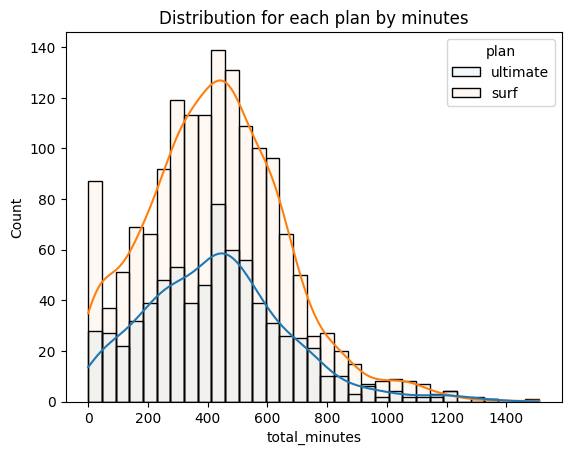

In [66]:
sns.histplot(data=monthly, x='total_minutes', hue='plan', kde=True, alpha=0.05)
plt.title('Distribution for each plan by minutes')
plt.show()

### Call Minutes Distribution
The distribution of monthly call minutes by plan is **slightly left-skewed**, but in both cases it closely resembles a normal distribution.  
For both Surf and Ultimate, the medians are very close, suggesting that users of both plans consume a **similar average number of minutes per month**.  
However, Ultimate users show **greater dispersion**, likely because they have more included minutes and therefore less incentive to limit their usage.

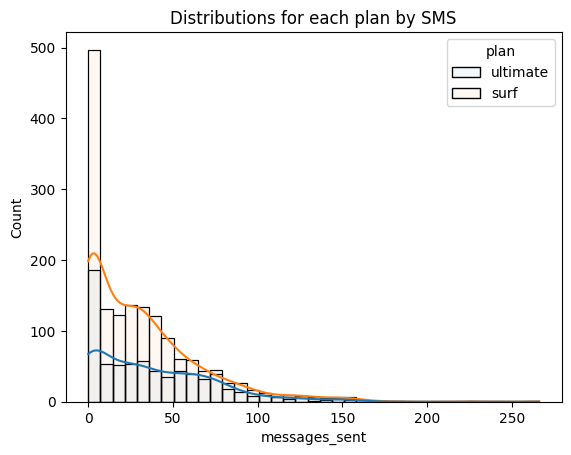

In [67]:
sns.histplot(data=monthly, x='messages_sent', hue='plan', kde=True, alpha=0.05)
plt.title('Distributions for each plan by SMS')
plt.show()

### SMS Usage Distribution
The distribution of sent messages is **strongly left-skewed** for both plans, with most values concentrated at zero or very low levels.  
This indicates that a large proportion of users **barely use SMS services**. Differences between plans are minimal, suggesting that SMS usage is not a key differentiator between Surf and Ultimate.


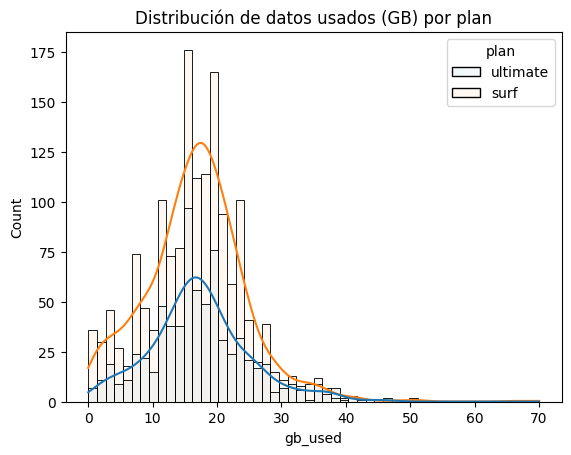

In [68]:
sns.histplot(data=monthly, x='gb_used', hue='plan', kde=True, alpha=0.05)
plt.title('Distribución de datos usados (GB) por plan')
plt.show()

### Data Usage Distribution
Data consumption shows a **wider distribution with positive skewness**, especially for the Ultimate plan.  
Most users consume a moderate amount of data, but a smaller group consumes significantly more, creating a long right tail.  
In contrast, Surf users show a stronger concentration at lower values, suggesting that data limits may restrict usage or that this group represents less intensive internet users.


Estadísticas de ingresos por plan:
       plan       mean          var
0      surf  60.706408  3067.835152
1  ultimate  72.313889   129.848486


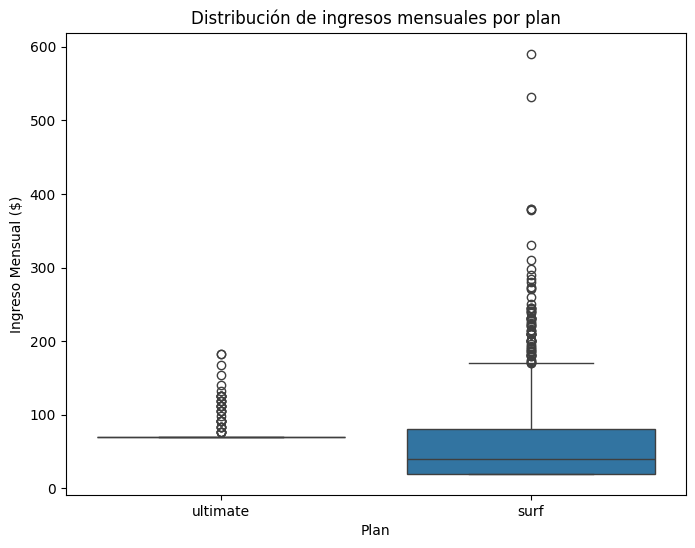

In [69]:
revenue_stats = monthly.groupby('plan')['monthly_revenue'].agg(['mean', 'var']).reset_index()
print("Estadísticas de ingresos por plan:")
print(revenue_stats)

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='monthly_revenue', data=monthly)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso Mensual ($)')
plt.show()

### Revenue Comparison by Plan
The boxplot clearly shows that the **Ultimate plan generates higher average monthly revenue** than the Surf plan.  
Although the Surf plan includes some outliers representing very high revenues from users who significantly exceeded their limits, the majority of Surf users generate **lower revenues** compared to Ultimate users.

The **lower variance** observed in Ultimate’s revenue distribution indicates that this plan provides **more predictable and consistent income**, which is a key advantage from a business perspective.


### Hypothesis Test 1  
**Do average revenues differ between Ultimate and Surf plans?**

**Null hypothesis (H₀):**  
The average revenue of users on the Ultimate and Surf plans is equal.

**Alternative hypothesis (H₁):**  
The average revenue of users on the Ultimate and Surf plans is different.

To test this hypothesis, an **independent samples t-test** (`scipy.stats.ttest_ind`) was used, since we are comparing the means of **two independent groups**, each corresponding to a different plan.

Equal variances cannot be assumed, so the test was performed assuming **unequal variances** (Welch’s t-test).

A **two-tailed test** was applied to determine whether there is any statistically significant difference between the two averages.


In [70]:
surf_revenue = monthly[monthly['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = monthly[monthly['plan'] == 'ultimate']['monthly_revenue']

alpha = 0.05

p_value = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print('Valor p:', p_value.pvalue)

if p_value.pvalue < alpha:
    print("Rechazamos la hipótesis nula: los ingresos promedio son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: no hay diferencia significativa.")

Valor p: 3.170390548113574e-15
Rechazamos la hipótesis nula: los ingresos promedio son diferentes.


### Hypothesis Test 2  
**Does average revenue differ between the New York–New Jersey area and other regions?**

**Null hypothesis (H₀):**  
The average revenue of users in the New York–New Jersey area is equal to that of users in other regions.

**Alternative hypothesis (H₁):**  
The average revenue of users in the New York–New Jersey area is different from that of users in other regions.

Nuevamente, voy a usar una prueba t para muestras independientes (ttest_ind),

In [71]:
monthly_with_city = monthly.merge(users_df[['user_id', 'city']], on='user_id', how='left')

ny_nj_revenue = monthly_with_city[
    monthly_with_city['city'].str.contains('NY|New York|New Jersey',
                                           case=False,
                                           na=False)]['monthly_revenue']

other_revenue = monthly_with_city[
    ~monthly_with_city['city'].str.contains('NY|New York|New Jersey',
                                            case=False, na=False)]['monthly_revenue']

alpha = 0.05

results_region = st.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)

print('Valor p:', results_region.pvalue)

if results_region.pvalue < alpha:
    print("Rechazamos la hipotesis nula: los ingresos promedio son diferentes por región.")
else:
    print("No podemos rechazar la hipotesis: los ingresos promedio no difieren significativamente.")

Valor p: 0.609789451337982
No podemos rechazar la hipotesis: los ingresos promedio no difieren significativamente.


# General Project Conclusion

After analyzing the data of the 500 Megaline customers and comparing the Surf and Ultimate plans, the following conclusions can be drawn:

## 1. User Behavior
- In general, the usage of minutes and data shows a more dispersed distribution in the Ultimate plan, while text message usage is low in both plans, with a distribution heavily skewed toward zero.
- Users on the Surf plan tend to consume fewer minutes and data on average than users on the Ultimate plan, although some Surf users significantly exceed their limits.

## 2. Revenue by Plan
- The analysis of average monthly revenue and the hypothesis test confirmed that there is a statistically significant difference in the average revenue generated by users of the Surf and Ultimate plans.
- The Ultimate plan generates higher average monthly revenue per user compared to the Surf plan.
- Although the Surf plan can generate high revenue in cases of excessive usage (as shown by outliers in the boxplot), most Surf users stay within their limits or exceed them by a smaller margin, resulting in lower average revenue and higher variability.

## 3. Regional Impact
- The hypothesis test comparing average revenue between users in the New York–New Jersey area and users from other regions did not find a statistically significant difference.
- This suggests that geographic location in these specific regions is not a determining factor in the amount of revenue generated by a user.

## Final Recommendation
Based on this analysis, the commercial department should consider focusing its advertising efforts on the Ultimate plan, as it consistently generates higher average revenue per user. Although the Surf plan attracts a segment with potential for high overage spending, the Ultimate user base appears to be more profitable and predictable on average.
